In [ ]:
import os
import math
import gc
from pathlib import Path

from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.filters import median
from skimage.morphology import disk
import matplotlib.patches as patches
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import median_filter
from pathlib import Path
from skimage.filters import gaussian




from src.Elements import Elements
from src.models import create_model 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
directories = [Path("data/model_weights/regression/cnn_vit"), Path("data/model_weights/regression/lt_vit"), Path("data/model_weights/regression/vit"), Path("data/model_weights/regression/xrfnet")]

objects = [
    ("matka_boska", torch.tensor(np.load("data/objects/processed/matka_boska_1x1_patches_discrete.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    ("matka_boska_discrete", torch.tensor(np.load("data/objects/processed/matka_boska_1x1_patches.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    ("pigment_palette", torch.tensor(np.load("data/objects/processed/pigment_palette_1x1_patches.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    ("pigment_palette_discrete", torch.tensor(np.load("data/objects/processed/pigment_palette_1x1_patches_discrete.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    ("sobieski", torch.tensor(np.load("data/objects/processed/sobieski_1x1_patches.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    ("sobieski_discrete", torch.tensor(np.load("data/objects/processed/sobieski_1x1_patches_discrete.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    ("gasecki_discrete", torch.tensor(np.load("data/objects/processed/gasecki_1x1_patches_discrete.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    ("gasecki", torch.tensor(np.load("data/objects/processed/gasecki_1x1_patches.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    ("bohomaz_discrete", torch.tensor(np.load("data/objects/bohomaz/Bohomaz_data_corr_total.npz", allow_pickle=True)["E_xy"], dtype=torch.float)),
    ("grave_discrete", torch.tensor(np.load("data/objects/grave/GraveDiscover_data_corr_total.npz", allow_pickle=True)["E_xy"], dtype=torch.float))

]

bohomaz = objects[-1][1]
max_vals = bohomaz.abs().max(dim=-1, keepdim=True).values + 1e-8
cube_normalized = bohomaz / max_vals
objects[-1] = (objects[-1][0], cube_normalized)

pigment_vs_pigment = torch.tensor(np.load("data/objects/pigment_vs_pigment.npy", allow_pickle=True), dtype=torch.float)
pigment_vs_pigment_noise = torch.tensor(np.load("data/objects/pigment_vs_pigment_noise.npy", allow_pickle=True), dtype=torch.float)
pigment_vs_pigment_noise_mh = torch.tensor(np.load("data/objects/pigment_vs_pigment_noise_mh.npy", allow_pickle=True), dtype=torch.float)

bboxes = {
    'mn': [(9, 25, 9, 25), (9, 25, 97, 113)],
    'fe': [(9, 25, 9, 25), (53, 69, 31, 47)],
    'ca': [(9, 25, 31, 47), (9, 25, 53, 69), (9, 25, 75, 91)],
    'zn': [(9, 25, 31, 47), (9, 25, 53, 69), (9, 25, 75, 91), (97, 113, 97, 113)],
    's': [(9, 25, 53, 69), (31, 47, 9, 25), (31, 47, 97, 113), (53, 69, 75, 91), (97, 113, 53, 69), (97, 113, 75, 91)],
    'as': [(9, 25, 53, 69), (31, 47, 97, 113)],
    'pb': [(9, 25, 75, 91), (75, 91, 9, 25), (75, 91, 53, 69)],
    'hg': [(31, 47, 9, 25)],
    'wood': [(31, 47, 31, 47)],
    'cr': [(31, 47, 53, 69)],
    'ti': [(31, 47, 75, 91)],
    'si': [(53, 69, 9, 25), (53, 69, 53, 69)],
    'zr': [(53, 69, 9, 25)],
    'na': [(53, 69, 53, 69)],
    'al': [(53, 69, 53, 69), (75, 91, 97, 113)],
    'k': [(53, 69, 75, 91), (53, 69, 97, 113)],
    'cd': [(53, 69, 75, 91)],
    'co': [(53, 69, 97, 113), (97, 113, 31, 47)],
    'sn': [(75, 91, 9, 25)],
    'cu': [(75, 91, 31, 47), (97, 113, 97, 113)],
    'ag': [(75, 91, 75, 91)],
    'si': [(53, 69, 9, 25), (53, 69, 53, 69)],
    'zn': [(9, 25, 31, 47), (9, 25, 53, 69), (9, 25, 75, 91), (97, 113, 97, 113), (97, 113, 9, 25)],
    'ba': [(97, 113, 53, 69)],
    'au': [(97, 113, 75, 91)]
}

def infer_model(model, e_xy, batch_size=256):
    H, W, C = e_xy.shape
    e_xy_flat = e_xy.view(-1, C)
    outputs = []

    with torch.no_grad():
        for i in range(0, len(e_xy_flat), batch_size):
            print(f"Batch {i // batch_size + 1}")
            batch = e_xy_flat[i:i + batch_size].unsqueeze(1)
            out = model(batch)
            outputs.append(out)

    return torch.cat(outputs, dim=0).view(H, W, -1).cpu()

def plot_output_maps(outputs, object_name, save_path, k=5, filtered=False, custom_ticks=False):
    depth = outputs.shape[2]
    topk_indices = torch.topk(outputs, k=k, dim=-1).indices.numpy()
    vmin, vmax = np.percentile(outputs, 1), np.percentile(outputs, 99)

    n_cols = 4
    n_rows = math.ceil(depth / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
    axes = axes.flatten()
    im = None

    for i in range(depth):
        ax = axes[i]
        slice_i = outputs[:, :, i]
        mask = np.any(topk_indices == i, axis=-1)
        masked = np.where(mask, slice_i, 0.0)

        if filtered:
            masked = median(masked, disk(2))

        im = ax.imshow(masked, cmap='turbo', vmin=vmin, vmax=vmax, interpolation="none")

        try:
            element = Elements.NUM2SYMBOL[i]
            title = f'{i + 1}: {element.capitalize()}'
        except IndexError:
            element = "wood" 
            title = f'{i + 1}: {element}'
        ax.set_title(title)

        if custom_ticks:
            ticks = list(Elements.LINES.keys())
            tick_pos = np.arange(0, len(ticks) * 20, 20)
            ax.set_xticks(tick_pos)
            ax.set_xticklabels(ticks, ha='left', fontsize=9, rotation=45)
            ax.set_yticks(tick_pos + 5)
            ax.set_yticklabels(ticks, fontsize=9)
            ax.xaxis.set_ticks_position('top')
            ax.tick_params(axis='x', length=0)
            ax.tick_params(axis='y', length=0)
        
        if "pigment_palette" in object_name:
            for (x1, x2, y1, y2) in bboxes[element]:
                width, height = y2 - y1 + 4, x2 - x1 + 4
                rect = patches.Rectangle((y1-2, x1-2), width, height, linewidth=3, edgecolor='#FF4FFF', facecolor='none')
                ax.add_patch(rect)
        elif "pigment_vs_pigment" in object_name:
            pass
        else:
            ax.set_xticks([])
            ax.set_yticks([])

    for j in range(depth, len(axes)):
        fig.delaxes(axes[j])

    if im:
        if custom_ticks:
            # Adjust layout to make room for vertical colorbar
            fig.subplots_adjust(right=0.88, hspace=0.4)
            cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
            cbar = fig.colorbar(im, cax=cbar_ax)
        else:
            # Use tight layout with space for colorbar
            fig.subplots_adjust(wspace=0.15, hspace=0.2, right=0.85)
            cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
            cbar = fig.colorbar(im, cax=cbar_ax)

        cbar.set_label("Relative counts")

    # Save figure
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close(fig)

def plot_top_abundances_and_filtered(outputs, save_path, k=5, filter_size=2, num_total_elements=17, num_colors_for_mapping=20):
    if isinstance(outputs, torch.Tensor):
        outputs = outputs.numpy()
    
    # Exclude the last channel if needed, as per the previous code's modification
    outputs = outputs[:,:,:-1]
    height, width, depth = outputs.shape
    
    # Get top-k indices and abundances
    topk_abundances, topk_indices = torch.topk(torch.from_numpy(outputs), k=k, dim=-1)
    topk_abundances = topk_abundances.numpy()
    topk_indices = topk_indices.numpy()

    if num_total_elements > num_colors_for_mapping:
        print(f"Warning: Number of elements ({num_total_elements}) is greater than available "
              f"colors ({num_colors_for_mapping}). Colors will repeat.")

    colors = plt.cm.get_cmap('tab20', num_colors_for_mapping)
    element_cmap = ListedColormap(colors.colors)
    
    bounds = np.arange(num_total_elements + 1) - 0.5
    element_norm = BoundaryNorm(bounds, element_cmap.N)

    save_path_filtered = save_path.parent / f"{save_path.stem}_top_abundances_filtered_maps_colored.png"
    save_path_filtered.parent.mkdir(parents=True, exist_ok=True)
    
    # Calculate the number of rows for a 2-column layout
    num_rows = math.ceil(k / 2)
    
    # Create a figure with a num_rows rows and 2 columns
    fig, axes = plt.subplots(num_rows, 2, figsize=(width / 50 * 2, height / 50 * num_rows), squeeze=False)

    for i in range(k):
        row_idx = i // 2
        col_idx = i % 2
        
        # Apply median filter
        filtered_top_element_indices = median_filter(topk_indices[:, :, i], size=filter_size)
        im = axes[row_idx, col_idx].imshow(filtered_top_element_indices, cmap=element_cmap, norm=element_norm, interpolation='none')
        
        # Set titles and remove ticks
        axes[row_idx, col_idx].set_title(f'Top {i+1} Abundant Element', fontsize=10)
        axes[row_idx, col_idx].set_xticks([])
        axes[row_idx, col_idx].set_yticks([])

    # Hide any unused subplots if k is odd
    if k % 2 != 0:
        axes[num_rows - 1, 1].axis('off')

    # Add a single colorbar for the entire figure, positioned to the right
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7]) # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=np.arange(num_total_elements))
    
    # Remove 'wood' from the labels
    cbar.ax.set_yticklabels([Elements.NUM2SYMBOL[j] for j in range(num_total_elements)])
    cbar.set_label('Element Identity', fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.savefig(save_path_filtered, bbox_inches='tight', dpi=300)
    plt.close(fig)

    return save_path_filtered




def evaluate_model_on_object(object_name: str, e_xy: torch.Tensor, model_paths: list[Path], output_root: Path):
    for model_path in model_paths:
        gc.collect()
        print(f"Evaluating {object_name} with model {model_path.name}")
        model = torch.load(model_path, weights_only=False).to(device)
        model.eval()
        model_name = model_path.stem

        e_xy[:, :, :256] = 0
        e_xy[:, :, -256:] = 0
        outputs = infer_model(model, e_xy)
        save_path = output_root / object_name / f"{model_name}.png"

        outputs = outputs / outputs.sum(dim=-1, keepdim=True)



        if object_name in ["pigment_vs_pigment", "pigment_vs_pigment_noise", "pigment_vs_pigment_noise_mh"]:
            plot_output_maps(outputs, object_name, save_path, filtered=False, custom_ticks=True)
        else:
            plot_output_maps(outputs, object_name, save_path, filtered=False)
        
        plot_top_abundances_and_filtered(outputs, save_path, k=5, filter_size=1, num_total_elements=16, num_colors_for_mapping=20)


def main():

    for object_name, e_xy in objects + [("pigment_vs_pigment", pigment_vs_pigment), ("pigment_vs_pigment_noise", pigment_vs_pigment_noise), ("pigment_vs_pigment_noise_mh", pigment_vs_pigment_noise_mh)]:
        gc.collect()
        model_paths = [Path("data/model_weights/regression/lt_vit/trial_lt_vit_2025-09-06 17:30:27.582761.pt")]

        output_root = Path("data", "evaluation")

        e_xy = e_xy.to(device)
        evaluate_model_on_object(object_name, e_xy, model_paths, output_root)
        del e_xy
        # for directory in directories:
        #     model_paths = [directory / filename for filename in os.listdir(directory) if (directory / filename).is_file()]

        #     output_root = Path("data", "evaluation")

        #     e_xy = e_xy.to(device)
        #     evaluate_model_on_object(object_name, e_xy, model_paths, output_root)
        # del e_xy
                            
print(device)
main()                            

cuda
Evaluating matka_boska with model trial_lt_vit_2025-09-06 17:30:27.582761.pt
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64
Batch 65
Batch 66
Batch 67
Batch 68
Batch 69
Batch 70
Batch 71
Batch 72
Batch 73
Batch 74
Batch 75
Batch 76
Batch 77
Batch 78
Batch 79
Batch 80
Batch 81
Batch 82
Batch 83
Batch 84
Batch 85
Batch 86
Batch 87
Batch 88
Batch 89
Batch 90
Batch 91
Batch 92
Batch 93
Batch 94
Batch 95
Batch 96
Batch 97
Batch 98
Batch 99
Batch 100
Batch 101
Batch 102
Batch 

/tmp/ipykernel_228594/2381442444.py:186: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_colors_for_mapping)
/tmp/ipykernel_228594/2381442444.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


Evaluating matka_boska_discrete with model trial_lt_vit_2025-09-06 17:30:27.582761.pt
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64
Batch 65
Batch 66
Batch 67
Batch 68
Batch 69
Batch 70
Batch 71
Batch 72
Batch 73
Batch 74
Batch 75
Batch 76
Batch 77
Batch 78
Batch 79
Batch 80
Batch 81
Batch 82
Batch 83
Batch 84
Batch 85
Batch 86
Batch 87
Batch 88
Batch 89
Batch 90
Batch 91
Batch 92
Batch 93
Batch 94
Batch 95
Batch 96
Batch 97
Batch 98
Batch 99
Batch 100
Batch 101
Batch 102
Ba

/tmp/ipykernel_228594/2381442444.py:186: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_colors_for_mapping)
/tmp/ipykernel_228594/2381442444.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


Evaluating pigment_palette with model trial_lt_vit_2025-09-06 17:30:27.582761.pt
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64


...

/tmp/ipykernel_228594/2381442444.py:186: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_colors_for_mapping)
/tmp/ipykernel_228594/2381442444.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


Evaluating pigment_vs_pigment_noise with model trial_lt_vit_2025-09-06 17:30:27.582761.pt
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64
Batch 65
Batch 66
Batch 67
Batch 68
Batch 69
Batch 70
Batch 71
Batch 72
Batch 73
Batch 74
Batch 75
Batch 76
Batch 77
Batch 78
Batch 79
Batch 80
Batch 81
Batch 82
Batch 83
Batch 84
Batch 85
Batch 86
Batch 87
Batch 88
Batch 89
Batch 90
Batch 91
Batch 92
Batch 93
Batch 94
Batch 95
Batch 96
Batch 97
Batch 98
Batch 99
Batch 100
Batch 101
Batch 10

/tmp/ipykernel_228594/2381442444.py:186: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_colors_for_mapping)
/tmp/ipykernel_228594/2381442444.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


Evaluating pigment_vs_pigment_noise_mh with model trial_lt_vit_2025-09-06 17:30:27.582761.pt
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64
Batch 65
Batch 66
Batch 67
Batch 68
Batch 69
Batch 70
Batch 71
Batch 72
Batch 73
Batch 74
Batch 75
Batch 76
Batch 77
Batch 78
Batch 79
Batch 80
Batch 81
Batch 82
Batch 83
Batch 84
Batch 85
Batch 86
Batch 87
Batch 88
Batch 89
Batch 90
Batch 91
Batch 92
Batch 93
Batch 94
Batch 95
Batch 96
Batch 97
Batch 98
Batch 99
Batch 100
Batch 101
Batch

/tmp/ipykernel_228594/2381442444.py:186: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_colors_for_mapping)
/tmp/ipykernel_228594/2381442444.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


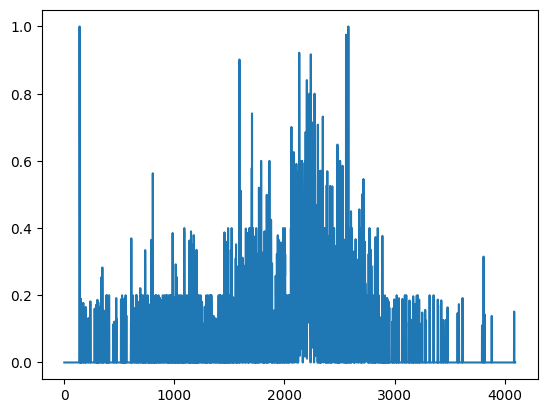

In [5]:
plt.plot(cube_normalized[20, 20])